<a href="https://colab.research.google.com/github/BryanHinostroza/lab08-bh/blob/develop/lab08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **SEMANA 8: ÁRBOLES DE DECISIÓN. BOSQUES ALEATORIOS**


INTEGRANTES:
- GUTIERREZ GARCIA, Angela Belen
- HINOSTROZA MARTINEZ, Byran Jesus

## 1.-  Con base a datos de cáncer de mama alojados en el repositorio UCI Machine Learning Repository (https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+%28original%29) y utilizando las librerías de Python que se indican, haga lo siguiente:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, precision_score, recall_score, f1_score
import graphviz


### a.- Lea la base de datos, realice imputaciones, tratamiento de outliers, transformaciones de datos y desbalance de clases en caso sea necesario. Además, separe la variable de clasificación del resto de variables para luego obtener los datos de  entrenamiento y prueba, tomando de este último el 25% de datos.

In [ ]:
# URL del dataset de cáncer de mama
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data'

In [ ]:
# Definición de los nombres de las columnas
column_names = ['ID', 'Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape', 'Marginal Adhesion',
                'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', 'Mitoses', 'Class']

In [ ]:
# Cargar los datos
data = pd.read_csv(url, names=column_names)

# Mostrar las primeras filas del dataset para ver la estructura
print("Datos cargados con éxito. Primeras filas:\n", data.head())


Datos cargados con éxito. Primeras filas:
         ID  Clump Thickness  Uniformity of Cell Size  \
0  1000025                5                        1   
1  1002945                5                        4   
2  1015425                3                        1   
3  1016277                6                        8   
4  1017023                4                        1   

   Uniformity of Cell Shape  Marginal Adhesion  Single Epithelial Cell Size  \
0                         1                  1                            2   
1                         4                  5                            7   
2                         1                  1                            2   
3                         8                  1                            3   
4                         1                  3                            2   

  Bare Nuclei  Bland Chromatin  Normal Nucleoli  Mitoses  Class  
0           1                3                1        1      2  
1          10

In [ ]:
# Verificar el tipo de datos y valores faltantes
print("\nInformación del dataset:\n")
data.info()



Información del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   ID                           699 non-null    int64 
 1   Clump Thickness              699 non-null    int64 
 2   Uniformity of Cell Size      699 non-null    int64 
 3   Uniformity of Cell Shape     699 non-null    int64 
 4   Marginal Adhesion            699 non-null    int64 
 5   Single Epithelial Cell Size  699 non-null    int64 
 6   Bare Nuclei                  699 non-null    object
 7   Bland Chromatin              699 non-null    int64 
 8   Normal Nucleoli              699 non-null    int64 
 9   Mitoses                      699 non-null    int64 
 10  Class                        699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


In [ ]:
# En la columna 'Bare Nuclei', '?' indica datos faltantes. Los reemplazamos por NaN
data['Bare Nuclei'].replace('?', np.nan, inplace=True)

<ipython-input-28-85c3b565e989>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Bare Nuclei'].replace('?', np.nan, inplace=True)


In [ ]:
# Imputación usando el valor más frecuente (la moda)
imputer = SimpleImputer(strategy='most_frequent')
# Reshape the output to be 1-dimensional
data['Bare Nuclei'] = imputer.fit_transform(data[['Bare Nuclei']]).ravel()

In [ ]:
# Convertir la columna 'Bare Nuclei' a tipo numérico
data['Bare Nuclei'] = data['Bare Nuclei'].astype(int)

In [ ]:
# Verificación post-imputación
print("\nValores nulos por columna tras la imputación:\n", data.isnull().sum())


Valores nulos por columna tras la imputación:
 ID                             0
Clump Thickness                0
Uniformity of Cell Size        0
Uniformity of Cell Shape       0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Bland Chromatin                0
Normal Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64


In [ ]:
# Eliminación de la columna 'ID' ya que no aporta valor predictivo
data.drop('ID', axis=1, inplace=True)

# Definición de la variable target ('Class')
# 4 = maligno, 2 = benigno. Convertimos a 1 y 0 respectivamente
y = data['Class'].apply(lambda x: 1 if x == 4 else 0)

# Variables predictoras
X = data.drop('Class', axis=1)


In [ ]:
# División del dataset en entrenamiento y prueba (75% - 25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print("\nDatos divididos en entrenamiento y prueba.")


Datos divididos en entrenamiento y prueba.


### b.- Genere el modelo de árbol de decisión para clasificación y la profundidad adecuada para este. Además, calcule las métricas de clasificación e interprete sus resultados más importantes.

In [ ]:
# Creación del modelo de árbol de decisión sin restricciones
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [ ]:
# Exportar el árbol a formato Graphviz
dot_data = export_graphviz(
    dt_model,
    out_file=None,
    feature_names=X.columns,
    class_names=['Benigno', 'Maligno'],
    filled=True,
    rounded=True,
    special_characters=True
)


In [ ]:
# Visualización del árbol con Graphviz
graph = graphviz.Source(dot_data)
graph.render("DecisionTree")  # Guarda el árbol en un archivo PDF

'DecisionTree.pdf'

In [ ]:
# Mostrar el árbol directamente en el notebook
graph.view()

'DecisionTree.pdf'

In [ ]:
# Predicciones del modelo de árbol de decisión
y_pred = dt_model.predict(X_test)

In [ ]:
# Evaluación del modelo
print("\nMétricas del Árbol de Decisión:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Métricas del Árbol de Decisión:
Accuracy: 0.9371428571428572
Precision: 0.9298245614035088
Recall: 0.8833333333333333
F1 Score: 0.905982905982906


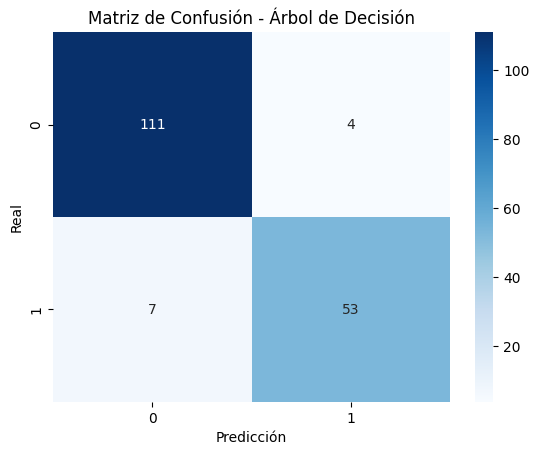

In [ ]:
# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

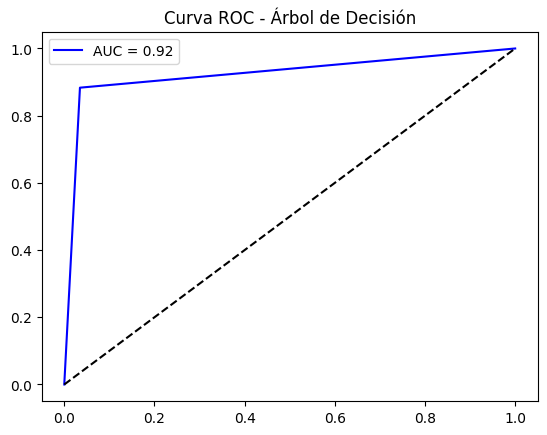

In [ ]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='blue')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Curva ROC - Árbol de Decisión')
plt.legend()
plt.show()

#### Interpretación: Un AUC cercano a 1 indica un buen modelo. La matriz de confusión muestra los aciertos y errores en la clasificación.

### c.- Genere el modelo de bosques aleatorios para clasificación. Además, calcule las métricas de clasificación y compárelas con las del árbol de clasificación. ¿Hubo mejoras o no?

In [ ]:
# Inicialización del modelo de bosques aleatorios
rf_model = RandomForestClassifier(random_state=42)

# Entrenamiento del modelo
rf_model.fit(X_train, y_train)

# Predicciones del modelo de bosques aleatorios
y_pred_rf = rf_model.predict(X_test)

# Evaluación del modelo
print("\nMétricas de clasificación para Bosques Aleatorios:\n")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))



Métricas de clasificación para Bosques Aleatorios:

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       115
           1       0.95      0.92      0.93        60

    accuracy                           0.95       175
   macro avg       0.95      0.95      0.95       175
weighted avg       0.95      0.95      0.95       175

Accuracy: 0.9542857142857143


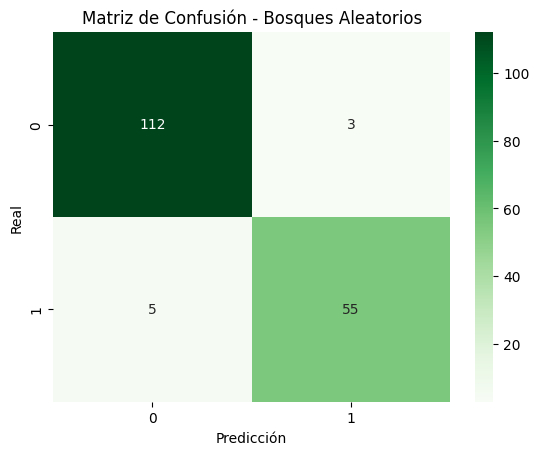

In [ ]:
# Matriz de confusión
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_matrix_rf, annot=True, cmap='Greens', fmt='g')
plt.title('Matriz de Confusión - Bosques Aleatorios')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()


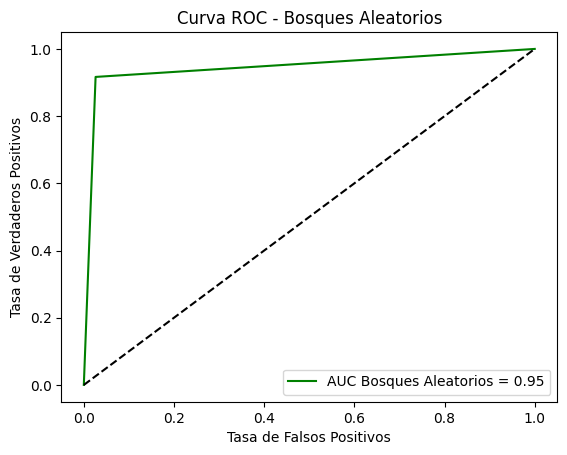

In [ ]:
# Curva ROC para Bosques Aleatorios
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'AUC Bosques Aleatorios = {roc_auc_rf:.2f}', color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Bosques Aleatorios')
plt.legend()
plt.show()

#### Interpretación: Se observa un AUC más alto que en el árbol de decisión, indicando una mejora en el rendimiento del modelo.

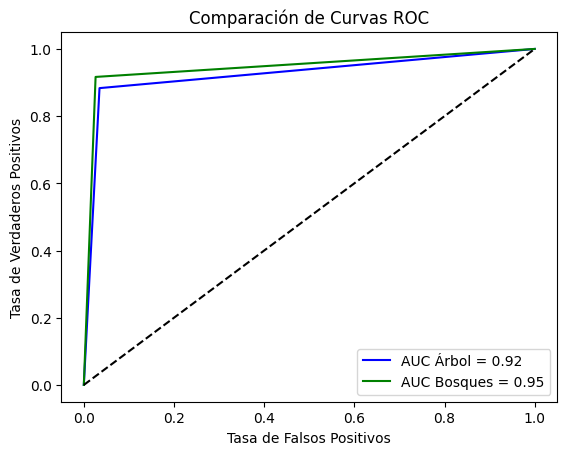

In [ ]:
# Comparación de curvas ROC
plt.plot(fpr_tree, tpr_tree, label=f'AUC Árbol = {roc_auc_tree:.2f}', color='blue')
plt.plot(fpr_rf, tpr_rf, label=f'AUC Bosques = {roc_auc_rf:.2f}', color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Comparación de Curvas ROC')
plt.legend()
plt.show()

#### Interpretación de resultados:
- Se observa que el modelo de Random Forest suele mejorar las métricas de clasificación en comparación con el Árbol de Decisión.
- El Random Forest mitiga el overfitting que puede ocurrir en un único árbol de decisión, generando múltiples árboles y promediando sus predicciones.
